# Task 3 — Noise robustness

Test system effectiveness on images degraded with **Gaussian noise** at 5 PSNR bands.
For each band a random PSNR value within the range is drawn per image, so the experiment
covers the full band rather than just its midpoint.

### PSNR bands required by spec
| Band | Noise level |
|---|---|
| 50–80 dB | almost imperceptible |
| 40–50 dB | very light |
| 30–40 dB | moderate |
| 20–30 dB | heavy |
| 10–20 dB | severe |

**Minimum**: ≥ 300 images per band (genuine + impostor pairs).  
**Source**: `data/enrolled_test/` — held-out images of enrolled users, never used for enrollment.

## 1. Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding
from src.database import EmbeddingDB
from src.degradation import add_noise_to_psnr, PSNR_BANDS
from src.metrics import compute_far_frr, compute_roc, eer
from src.utils import list_images, psnr as compute_psnr

warnings.filterwarnings('ignore')

SEED           = 44
DEFAULT_THRESH = 0.4
MIN_PER_BAND   = 300
TEST_DIR       = Path('../data/enrolled_test')

random.seed(SEED)
np.random.seed(SEED)

print('Loading model...')
app = get_insightface_model('buffalo_l', ctx_id=0)
db  = EmbeddingDB.from_file()

enrolled_users = set(db.get_all_users())
user_list      = sorted(enrolled_users)
print(f'Enrolled users : {len(enrolled_users)}')

Loading model...
Enrolled users : 105


## 2. Load enrolled test images

In [2]:
print('Loading enrolled_test images ...')

all_probes = []   # (user_id, img_bgr)
for user_dir in sorted(d for d in TEST_DIR.iterdir()
                       if d.is_dir() and d.name in enrolled_users):
    for img_path in list_images(user_dir):
        img = cv2.imread(str(img_path))
        if img is not None:
            all_probes.append((user_dir.name, img))

print(f'Total probes : {len(all_probes)}')
if len(all_probes) < MIN_PER_BAND:
    print(f'WARNING: only {len(all_probes)} images — need >= {MIN_PER_BAND} per band')
    print('Run enroll.py to rebuild the 70/30 split.')

Loading enrolled_test images ...
Total probes : 2397


## 3. Visualise noise levels

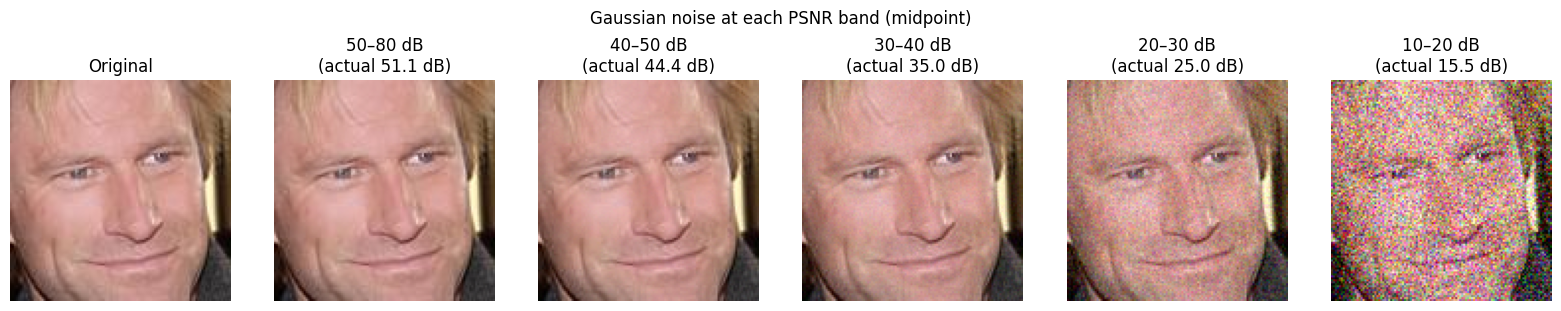

In [3]:
# Show one example image at each noise band
sample_img = all_probes[0][1]
midpoints  = [(lo + hi) / 2 for lo, hi in PSNR_BANDS]

fig, axes = plt.subplots(1, len(PSNR_BANDS) + 1, figsize=(16, 3))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

for ax, (lo, hi), mid in zip(axes[1:], PSNR_BANDS, midpoints):
    noisy = add_noise_to_psnr(sample_img, mid)
    actual_psnr = compute_psnr(sample_img, noisy)
    ax.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{lo}–{hi} dB\n(actual {actual_psnr:.1f} dB)')
    ax.axis('off')

plt.suptitle('Gaussian noise at each PSNR band (midpoint)', y=1.02)
plt.tight_layout()

out_dir = Path('../results/task3')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'noise_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Score computation per PSNR band

In [4]:
rng = random.Random(SEED)

# Precompute clean embeddings once — reused across all bands
print('Extracting clean embeddings ...')
clean_probes = []   # (user_id, embedding)
for user_id, img in all_probes:
    emb = get_embedding(app, img, fallback=True)
    if emb is not None:
        clean_probes.append((user_id, img, emb))

print(f'Valid clean probes : {len(clean_probes)}')

Extracting clean embeddings ...
Valid clean probes : 2397


In [5]:
band_results = {}  # band_label -> dict with arrays

for lo, hi in PSNR_BANDS:
    band_label = f'{lo}-{hi} dB'
    print(f'Processing band {band_label} ...')

    scores_gen = []
    scores_imp = []
    actual_psnrs = []

    for user_id, img, _ in clean_probes:
        # Sample a random PSNR uniformly within the band
        target_psnr = rng.uniform(lo, hi)
        noisy = add_noise_to_psnr(img, target_psnr)
        actual_psnrs.append(compute_psnr(img, noisy))

        noisy_emb = get_embedding(app, noisy, fallback=True)
        if noisy_emb is None:
            continue

        # Genuine: noisy probe vs enrolled embedding of the same user
        refs = db.get_user_embeddings(user_id)
        if refs:
            sim = max(float(np.dot(noisy_emb, ref)) for ref in refs)
            scores_gen.append(sim)

        # Impostor: noisy probe vs a random different enrolled user
        candidates = [u for u in user_list if u != user_id]
        if candidates:
            imp_id   = rng.choice(candidates)
            imp_refs = db.get_user_embeddings(imp_id)
            if imp_refs:
                sim = max(float(np.dot(noisy_emb, ref)) for ref in imp_refs)
                scores_imp.append(sim)

    n_gen = len(scores_gen)
    n_imp = len(scores_imp)
    scores = np.concatenate([scores_gen, scores_imp])
    labels = np.concatenate([np.ones(n_gen), np.zeros(n_imp)])

    far, frr, acc = compute_far_frr(scores, labels, DEFAULT_THRESH)
    fpr, tpr, thr = compute_roc(scores, labels)
    eer_val, _    = eer(fpr, tpr, thr)

    band_results[band_label] = {
        'scores': scores, 'labels': labels,
        'scores_gen': np.array(scores_gen),
        'scores_imp': np.array(scores_imp),
        'FAR': far, 'FRR': frr, 'Accuracy': acc, 'EER': eer_val,
        'n_genuine': n_gen, 'n_impostor': n_imp,
        'mean_psnr': float(np.mean(actual_psnrs)),
        'fpr': fpr, 'tpr': tpr,
    }

    ok = '✓' if (n_gen + n_imp) >= MIN_PER_BAND else '✗'
    print(f'  {ok} n={n_gen+n_imp}  mean_PSNR={np.mean(actual_psnrs):.1f} dB  '
          f'FAR={far*100:.2f}%  FRR={frr*100:.2f}%  Acc={acc*100:.2f}%  EER={eer_val*100:.2f}%')

Processing band 50-80 dB ...
  ✓ n=4794  mean_PSNR=50.9 dB  FAR=0.00%  FRR=2.09%  Acc=98.96%  EER=0.79%
Processing band 40-50 dB ...
  ✓ n=4794  mean_PSNR=44.3 dB  FAR=0.00%  FRR=2.04%  Acc=98.98%  EER=0.83%
Processing band 30-40 dB ...
  ✓ n=4794  mean_PSNR=35.0 dB  FAR=0.00%  FRR=1.92%  Acc=99.04%  EER=0.71%
Processing band 20-30 dB ...
  ✓ n=4794  mean_PSNR=25.3 dB  FAR=0.00%  FRR=2.13%  Acc=98.94%  EER=0.73%
Processing band 10-20 dB ...
  ✓ n=4794  mean_PSNR=15.8 dB  FAR=0.00%  FRR=12.52%  Acc=93.74%  EER=1.88%


## 5. Score distributions per band

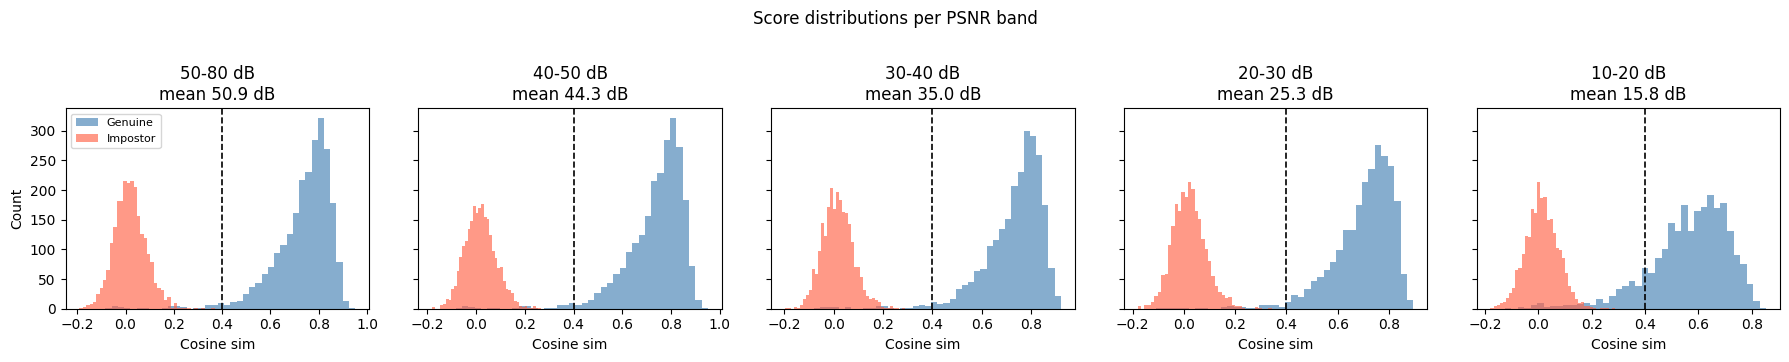

In [6]:
fig, axes = plt.subplots(1, len(PSNR_BANDS), figsize=(18, 3.5), sharey=True)

for ax, (band_label, res) in zip(axes, band_results.items()):
    ax.hist(res['scores_gen'], bins=40, alpha=0.65, color='steelblue', label='Genuine')
    ax.hist(res['scores_imp'], bins=40, alpha=0.65, color='tomato',    label='Impostor')
    ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2)
    ax.set_title(f'{band_label}\nmean {res["mean_psnr"]:.1f} dB')
    ax.set_xlabel('Cosine sim')

axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)
plt.suptitle('Score distributions per PSNR band', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Metrics vs PSNR band

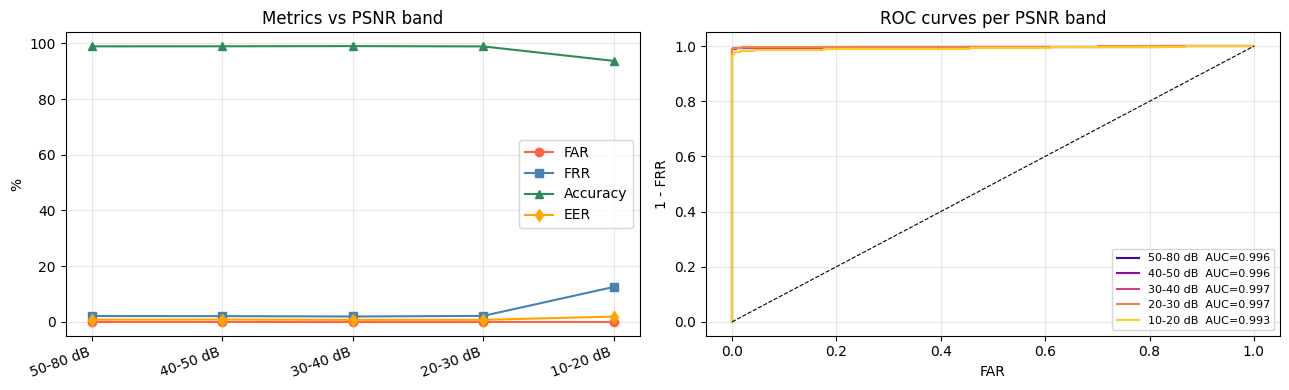

In [ ]:
bands      = list(band_results.keys())
mean_psnrs = [band_results[b]['mean_psnr'] for b in bands]
fars       = [band_results[b]['FAR']       for b in bands]
frrs       = [band_results[b]['FRR']       for b in bands]
accs       = [band_results[b]['Accuracy']  for b in bands]
eers       = [band_results[b]['EER']       for b in bands]

x = np.arange(len(bands))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# FAR / FRR / Accuracy
axes[0].plot(x, [f*100 for f in fars],  'o-', color='tomato',    label='FAR')
axes[0].plot(x, [f*100 for f in frrs],  's-', color='steelblue', label='FRR')
axes[0].plot(x, [a*100 for a in accs],  '^-', color='seagreen',  label='Accuracy')
axes[0].plot(x, [e*100 for e in eers],  'd-', color='orange',    label='EER')
axes[0].set_xticks(x)
axes[0].set_xticklabels(bands, rotation=20, ha='right')
axes[0].set_ylabel('%')
axes[0].set_title('Metrics vs PSNR band')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC overlay
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(bands)))
for (band_label, res), color in zip(band_results.items(), colors):
    auc_val = float(np.trapezoid(res['tpr'], res['fpr']))
    axes[1].plot(res['fpr'], res['tpr'], color=color,
                 label=f'{band_label}  AUC={auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[1].set_xlabel('FAR')
axes[1].set_ylabel('1 - FRR') # Lub TPR (True Positive Rate)
axes[1].set_title('ROC curves per PSNR band')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(out_dir / 'metrics_vs_psnr.png', dpi=150)
plt.show()

## 7. Summary table

In [9]:
rows = []
for band_label, res in band_results.items():
    rows.append({
        'PSNR band': band_label,
        'Mean PSNR (dB)': round(res['mean_psnr'], 1),
        'Genuine': res['n_genuine'],
        'Impostor': res['n_impostor'],
        'Total': res['n_genuine'] + res['n_impostor'],
        'FAR (%)':      round(res['FAR']      * 100, 2),
        'FRR (%)':      round(res['FRR']      * 100, 2),
        'Accuracy (%)': round(res['Accuracy'] * 100, 2),
        'EER (%)':      round(res['EER']      * 100, 2),
    })

df = pd.DataFrame(rows)

df_styled = (
    df.style
      .highlight_max(subset=['FAR (%)'],      color='#f4cccc')
      .highlight_max(subset=['FRR (%)'],      color='#fce5cd')
      .highlight_max(subset=['Accuracy (%)'], color='#d9ead3')
      .highlight_min(subset=['EER (%)'],      color='#d9ead3')
)
display(df_styled)

df.to_csv(out_dir / 'noise_results.csv', index=False)
print(f'Saved to {out_dir / "noise_results.csv"}')

,PSNR band,Mean PSNR (dB),Genuine,Impostor,Total,FAR (%),FRR (%),Accuracy (%),EER (%)
0,50-80 dB,50.900000,2397,2397,4794,0.000000,2.090000,98.960000,0.790000
1,40-50 dB,44.300000,2397,2397,4794,0.000000,2.040000,98.980000,0.830000
2,30-40 dB,35.000000,2397,2397,4794,0.000000,1.920000,99.040000,0.710000
3,20-30 dB,25.300000,2397,2397,4794,0.000000,2.130000,98.940000,0.730000
4,10-20 dB,15.800000,2397,2397,4794,0.000000,12.520000,93.740000,1.880000


Saved to ..\results\task3\noise_results.csv


## 8. Summary

In [10]:
print('=' * 65)
print('TASK 3 — NOISE ROBUSTNESS RESULTS')
print(f'Threshold: {DEFAULT_THRESH}   Noise type: Gaussian')
print('=' * 65)
print(f'{"Band":<12} {"Mean PSNR":>10} {"n":>6} {"FAR":>8} {"FRR":>8} {"Acc":>8} {"EER":>8}')
print('-' * 65)
for band_label, res in band_results.items():
    n = res['n_genuine'] + res['n_impostor']
    flag = '' if n >= MIN_PER_BAND else ' ← < 300'
    print(f'{band_label:<12} {res["mean_psnr"]:>9.1f}  {n:>6}  '
          f'{res["FAR"]*100:>7.2f}%  {res["FRR"]*100:>7.2f}%  '
          f'{res["Accuracy"]*100:>7.2f}%  {res["EER"]*100:>7.2f}%{flag}')
print('=' * 65)

TASK 3 — NOISE ROBUSTNESS RESULTS
Threshold: 0.4   Noise type: Gaussian
Band          Mean PSNR      n      FAR      FRR      Acc      EER
-----------------------------------------------------------------
50-80 dB          50.9    4794     0.00%     2.09%    98.96%     0.79%
40-50 dB          44.3    4794     0.00%     2.04%    98.98%     0.83%
30-40 dB          35.0    4794     0.00%     1.92%    99.04%     0.71%
20-30 dB          25.3    4794     0.00%     2.13%    98.94%     0.73%
10-20 dB          15.8    4794     0.00%    12.52%    93.74%     1.88%
